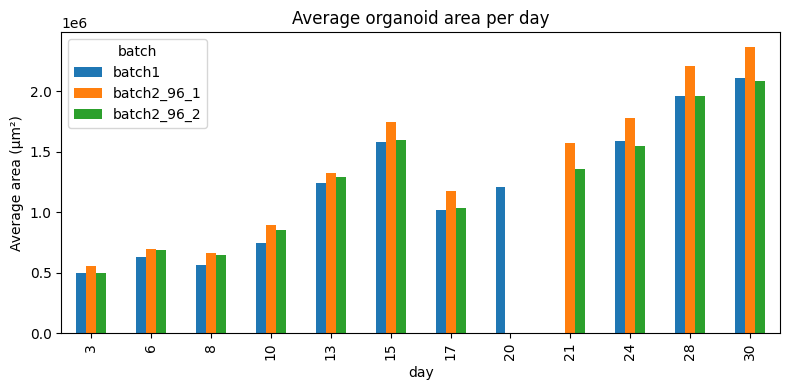

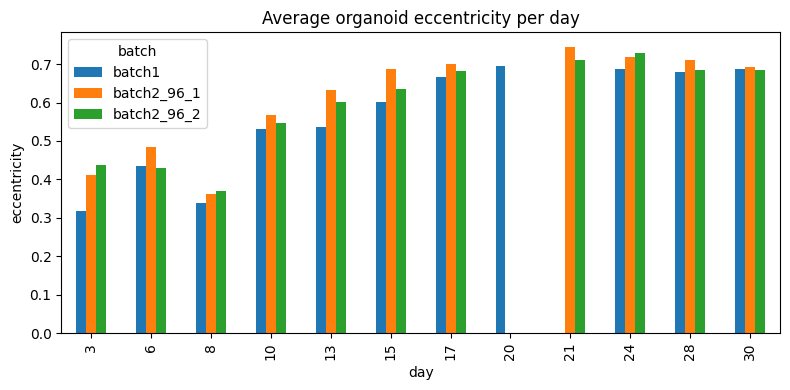

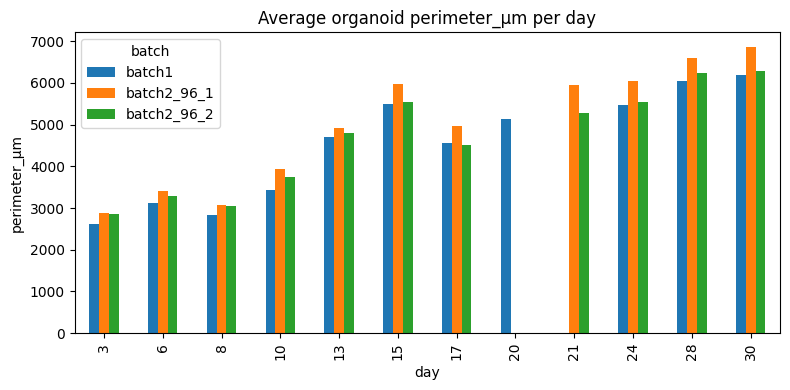

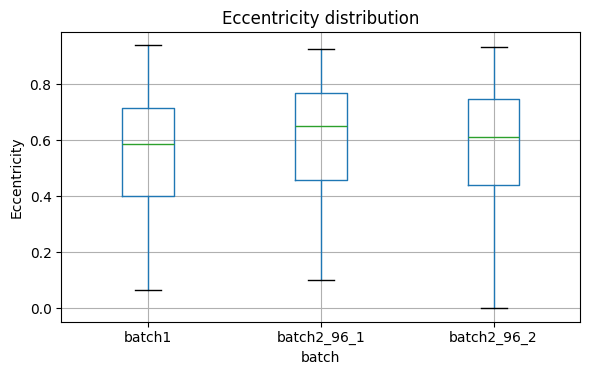

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

csv_path = Path("/net/projects2/promega/data-analysis/output/processed_dataset_256x192/mask_metrics.csv")
df = pd.read_csv(csv_path)

# ── keep batches 1 & 2 ──
df = df[df["batch_day"].isin(["batch1", "batch2_96_1", "batch2_96_2"])].copy()

# ── day and batch columns ──
df["day"]   = (
    df["img_id"]
      .str.extract(r"Dy(\d+)", expand=False)   # pulls 03, 06, 28 …
      .astype(int)
)
df["batch"] = df["batch_day"]                 # already “batch1/2”

# ── 1) average area per day ──
avg_area = df.groupby(["batch", "day"])["area_μm2"].mean().unstack(level=0)
avg_area.plot(kind="bar", figsize=(8,4))
plt.ylabel("Average area (µm²)")
plt.title("Average organoid area per day")
plt.tight_layout()
plt.show()

# ── 1) average area per day ──
avg_area = df.groupby(["batch", "day"])["eccentricity"].mean().unstack(level=0)
avg_area.plot(kind="bar", figsize=(8,4))
plt.ylabel("eccentricity")
plt.title("Average organoid eccentricity per day")
plt.tight_layout()
plt.show()

# ── 1) average area per day ──
avg_area = df.groupby(["batch", "day"])["perimeter_μm"].mean().unstack(level=0)
avg_area.plot(kind="bar", figsize=(8,4))
plt.ylabel("perimeter_µm")
plt.title("Average organoid perimeter_µm per day")
plt.tight_layout()
plt.show()

# ── 2) eccentricity distribution ──
df.boxplot(column="eccentricity", by="batch", figsize=(6,4))
plt.suptitle("")
plt.title("Eccentricity distribution")
plt.ylabel("Eccentricity")
plt.tight_layout()
plt.show()


In [8]:
print(df.columns)

Index(['area_μm2', 'perimeter_μm', 'major_ax_μm', 'minor_ax_μm',
       'eccentricity', 'img_id', 'batch_day', 'day', 'batch'],
      dtype='object')
